<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Cross validation and train-test splits


### Learning Objectives

### Core
- Describe train-test split and cross-validation
- Explain why we want to use these validation techniques and how they differ
- Split data into test and training sets using both train-test split and cross validation 
- Apply both techniques to score a model

### Target
- Use sklearn to split into training and test sets
- Use sklearn for cross validation

### Stretch
- Describe why it is useful to have an additional hold-out test set
- Explain when it might be a good idea to shuffle the dataset before cross validation

## Overfitting and underfitting

---

### Understanding Underfitting and Overfitting:
- **Overfit Model**: Overfitting occurs when a statistical model or machine learning algorithm captures the noise of the data. It occurs when the model or the algorithm fits the data too well.
Overfitting a model result in good accuracy for training data set but poor results on new data sets. Such a model is not of any use in the real world as it is not able to predict outcomes for new cases. 


- **Underfit Model**: Underfitting occurs when a statistical model or machine learning algorithm cannot capture the underlying trend of the data. Intuitively, underfitting occurs when the model or the algorithm does not fit the data well enough. It is often a result of an excessively simple model. By simple we mean that the missing data is not handled properly, no outlier treatment, removing of irrelevant features or features which do not contribute much to the predictor variable.

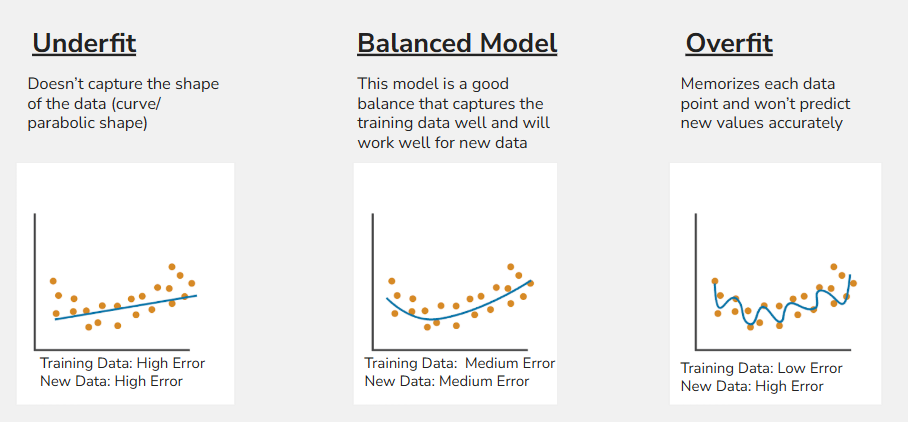
<br>
<small style="color: gray;">Source: https://www.mathworks.com/discovery/overfitting.html</small>


**What is wrong with the first model?**
- The underfit model falls short of capturing the complexity of the "true model" of the data.

**What is wrong with the third model?**
- The overfit model is too complex and is modeling random noise in the data.

**The middle model is a good compromise.**
- It approximates the complexity of the true model and does not model random noise in our sample as true relationships.

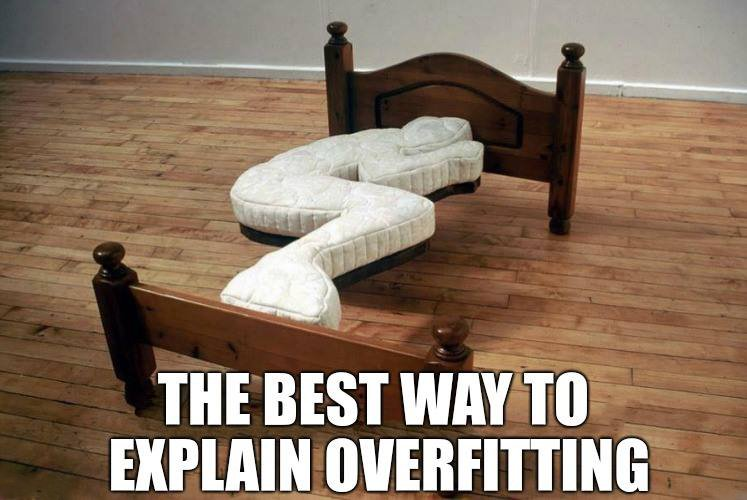
<br>
<small style="color: gray;">Source: https://jashrathod.github.io/2021-09-30-underfitting-overfitting-and-regularization</small>

<a name="train-test-split"></a>

### BIAS? VARIANCE?

*   Visually, we are building a
model where the bulls-eye is
the goal
* Each individual hit is one
prediction based on our model
* Critically, the success of our
model (low variance, low bias)
depends on the training data present


<center>
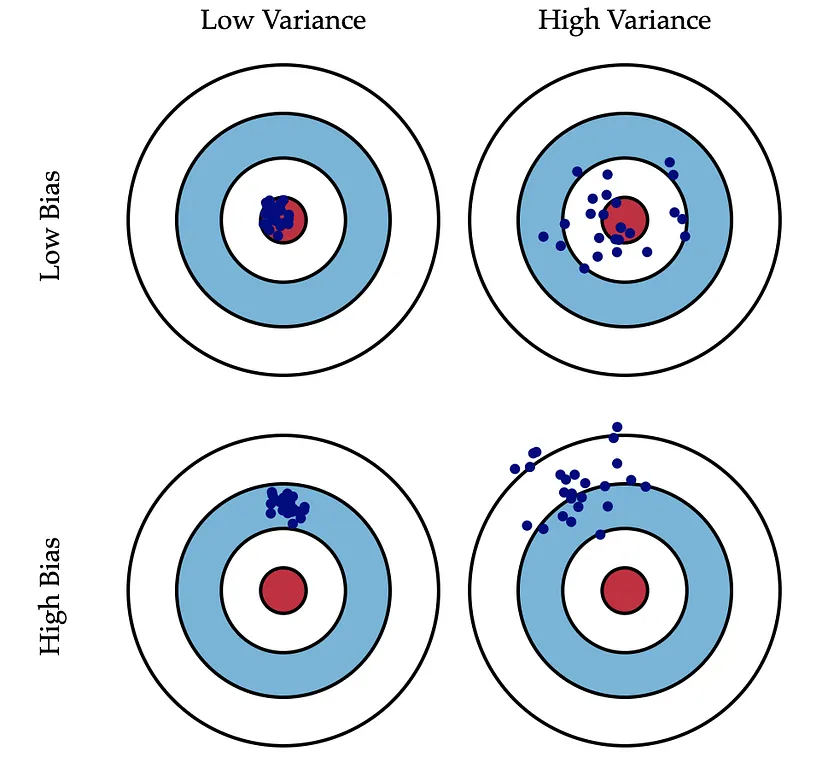
</center>

# Creating Models That Are Generalized
---

## Making a Prediction From a Sample

We often assume that our data set contains every sample for a given problem. In other words, the whole population.  In cases like the Titanic data set, that is true. Although it's convenient, in the real world all you typically have is a **sample** of data. This may sound like a contentious statement, but the point of machine learning is to generalize from a sample of data to the underlying population. If you already have data for an entire population, then you have no need for machine learning: you can apply statistics directly and get optimal answers!

So how can we get our models to generalize well?

**Methods:**   
1. **Train-test-split**:
     - Is useful if cross-validation is not practical (e.g. it takes too long to train)
     - It is also useful for computing a quick confusion matrix (for classification models)
     - You could also use this as a final step after the model is finalized (often called evaluating the model against a validation set)
1. **Cross-validation** is the gold standard for estimating accuracy and comparing accuracy across models for many model types.
1. **Three-way split** combines cross-validation and the train-test-split. It takes an initial split to be used as a final validation set, then uses cross-validation on the rest.

## Part I: Train-test split and model validation
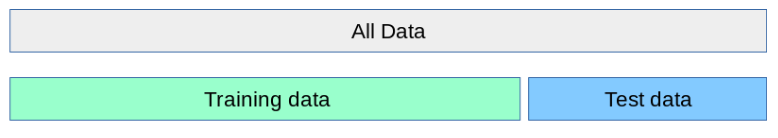

---

So far we've focused on fitting the best model to our data. But is this the best model for our sample data or the best model overall? How do we know?

In practice, we need to validate our model's ability to generalize to new data. One very popular method for performing model validation is by splitting our data into subsets: data that we *train* our model on, and data that we *test* our model on.

The most basic type of "hold-out" validation is called **train-test split**. We split our data into two pieces:

> **"Training set":** the subset of the data that we fit our model on.

> **"Testing set":** the subset of the data that we evaluate the quality of our predictions on.

**Test/train split benefits:**
- Testing data can be a proxy for "future" data; for prediction-oriented models it is critical to make sure a model performing well on current data will likely perform well on future data.
- Can help diagnose and avoid overfitting via model tuning.
- Improve the quality of our predictions.



<a id='cross-val-k-fold'></a>

<a id='demo'></a>

### Train-test split with sklearn demonstration

---

Let's use sklearn to load everyone's favorite data set: the boston housing data.

In [18]:
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn import metrics

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.style.use('fivethirtyeight')


import warnings
warnings.filterwarnings('ignore')
# %autosave 0

### Loading Boston Housing Dataset


In [2]:
# Load the Boston Housing dataset
df = pd.read_csv("./data/BostonHousing2.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<a id='heatmap'></a>

### Plot a heatmap of the correlation matrix

Heatmaps are a great way to visually examine the correlation structure of your predictors. 

> Keep in mind that pearson correlations between non-dummy-coded categorical variables and other variables are invalid!


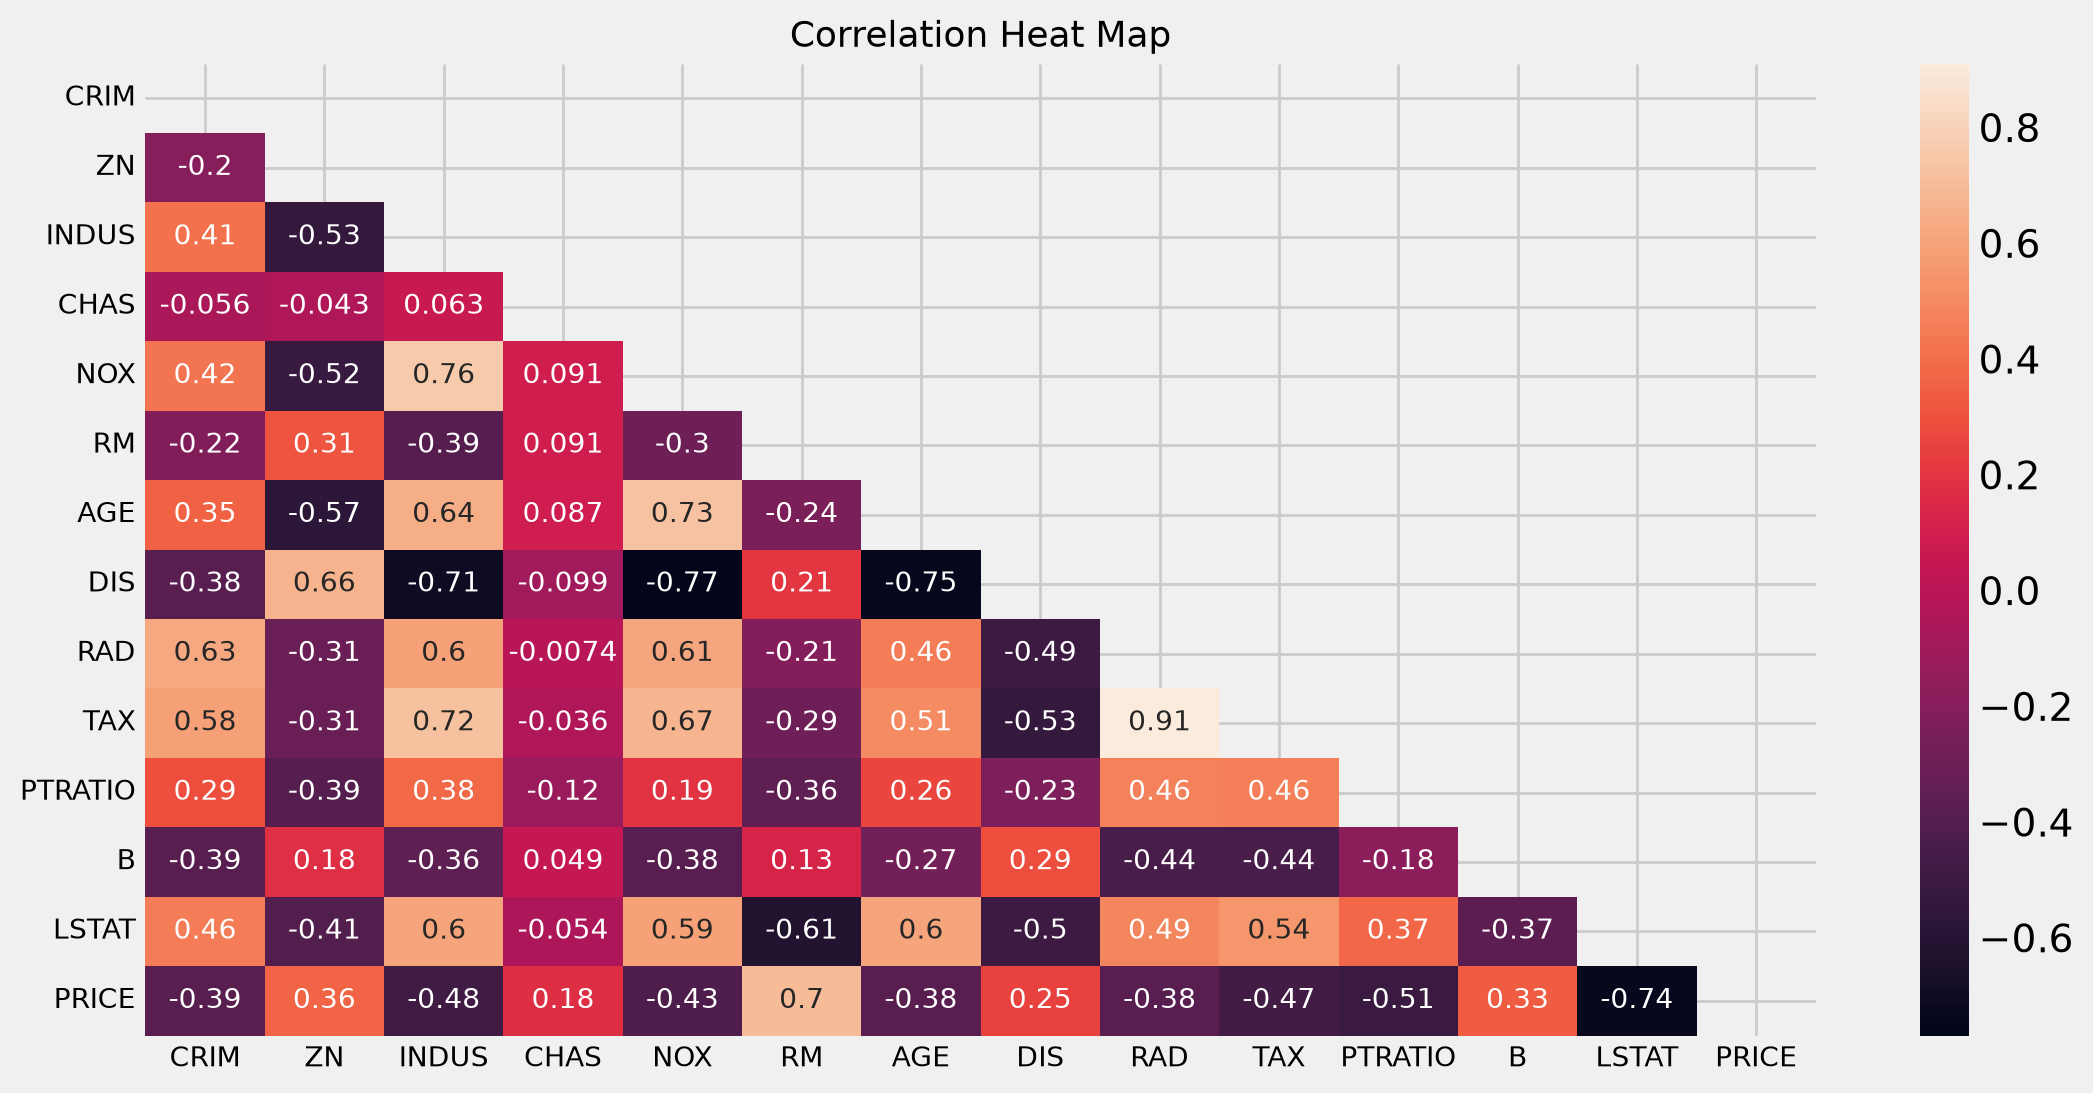

In [3]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True,mask=np.triu(df.corr()),annot_kws={"size": 10})
plt.title('Correlation Heat Map', size=13)
plt.yticks(rotation = 0)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


<a id='single-predictor'></a>

### Select multiple predictor for the model



In [4]:
# Select features 'AGE','RM','TAX','PTRATIO','LSTAT'
X=df[['AGE','RM','TAX','PTRATIO','LSTAT']]
X.head()


,AGE,RM,TAX,PTRATIO,LSTAT
0,65.2,6.575,296,15.3,4.98
1,78.9,6.421,242,17.8,9.14
2,61.1,7.185,242,17.8,4.03
3,45.8,6.998,222,18.7,2.94
4,54.2,7.147,222,18.7,5.33


In [5]:
# select our target which is PRICE
y=df['PRICE']
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: PRICE, dtype: float64

#### It is good practice to plot the variable against the target to confirm the relationship visually.

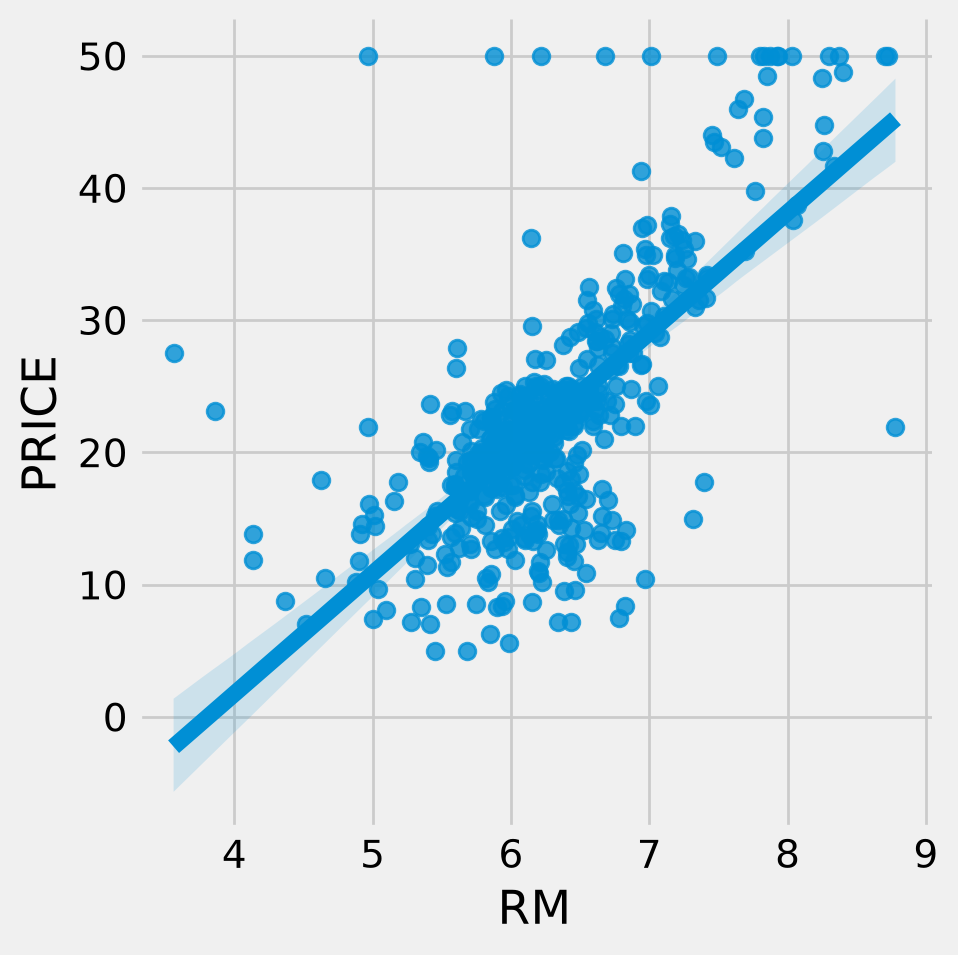

In [7]:
# Just to see the relationship using seaborn
# use sns.lmplot
sns.lmplot(data=df, x='RM', y='PRICE')
plt.show()


### Sklearn's `train_test_split` function

Train test split using sklearn is easy. Load the `train_test_split` function:

```python
from sklearn.model_selection import train_test_split
```
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

**Arguments**:
- `*arrays`: Any number of arrays/matrices to split up into training and testing (they should be the same length).
- `test_size`: an integer for exact size of the test subset or a float for a percentage
- `train_size`: alternatively you can specify the training size
- `shuffle (default=True)`: Whether or not to shuffle the data before splitting. 
- `stratify`: supply a vector to stratify the split (more important in classification tasks)

**Perform a 75-25 split of our `X` and `y`:**

In [8]:
# default test split is 0.25 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25,random_state=1)



In [9]:
# Check the shape of train and test splits
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(379, 5) (379,)
(127, 5) (127,)


Note that we could always split the data up manually. 

#### Random State Explained Simply

##### What is `random_state`?

Think of `random_state` as a **"seed number"** that controls randomness in machine learning.

##### Simple Analogy 🎲
- **Without `random_state`**: Like rolling a dice - completely unpredictable results every time
- **With `random_state=42`**: Like having a programmed dice - same results every time

##### Why Use It? 🔄
**Reproducibility** - You get the same results every time you run your code:
- Easier to debug
- Fair model comparisons  
- Others can reproduce your work

##### Example 📝
```python
# Results change every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<a id='fit-on-train'></a>

### Fit a linear regression on the training set

Using the training `X` and training `y`, we can fit a linear regression with sklearn's `LinearRegression`.

In [10]:
# instantiate the linear regression and fit
lr = LinearRegression()
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.02, 3.53,-0. ,-0.91,-0.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['AGE','RM','TAX','PTRATIO','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,24.77
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [13]:
X.columns

Index(['AGE', 'RM', 'TAX', 'PTRATIO', 'LSTAT'], dtype='str')

In [11]:
# what is the intercept?
lr.intercept_


np.float64(24.77016766817843)

In [12]:
# what is the coefficient?
lr.coef_


array([ 1.76612135e-02,  3.52704862e+00, -1.85772614e-03, -9.10067333e-01,
       -6.28858749e-01])

<a id='score-on-test'></a>

### Calculate the $R^2$ score on the training data

After we have constructed our model on the training set, we can evaluate how well our model performs on this training data set.

In [14]:
# calculate R2 on training data
lr.score(X_train, y_train)

0.657245103403813

### Calculate the $R^2$ score on the test data

After we have constructed our model on the training set, we can evaluate how well our model performs on data it did not have any exposure to.

In [15]:
# calculate R2 on test data
lr.score(X_test, y_test)


0.727734849017287

### <font color='red'>To do: </font>
* Go back, and split the data into 70-30 and see if the score is changing. Write a line or two on what do you learn?
* Is the performance different? Does that meet your expectations?

## Part II: Cross Validation

Using train-test split it can happen that the train and test sets are not really representative of the whole data distribution. For example, if you are not careful it is easy to take a non-random split. 

Suppose we have salary data on technical professionals that is composed 80% of data from London and 20% elsewhere and is sorted by county. If we split our data into 80% training data and 20% testing data we might accidentally select all the London data to train and all the non-London data to test. In this case we have still overfit our data set because we did not sufficiently randomise the data. A method to reduce this kind of bias is to use cross validation.

### K-Fold cross-validation

---

K-Fold cross-validation takes the idea of a single train-test split and expands this to *multiple tests* across different train-test splits of your data.

For example, if you determine your training set will contain 2/3 of the data and your testing set will contain the other 1/3, you could have 3 different 2/3 splits where the test set in each is a different set of observations. We have:
- 3 (K=3) training sets
- 3 (K=3) corresponding test sets

**K-Fold cross-validation builds K models, one for each train-test pair, and evaluates those models on each respective test-set.**



### K-Fold cross-validation visually

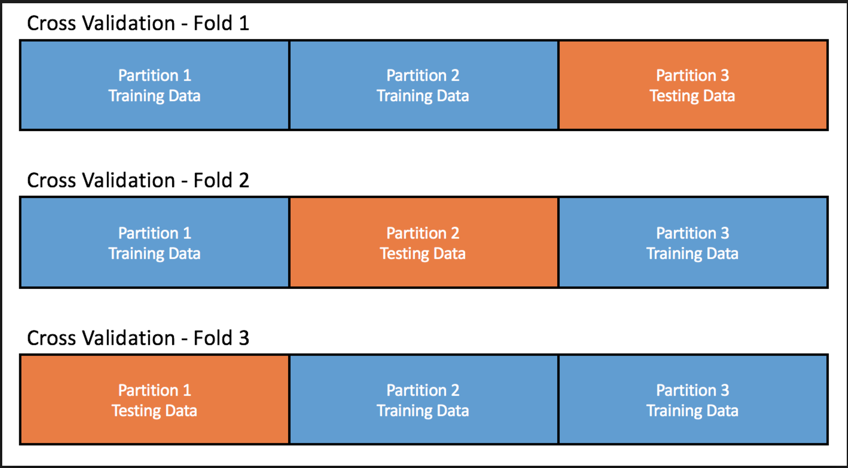

---

Cross-validation helps us to understand how a model parameterization may perform in a variety of cases. **The K-Fold cross-validation procedure can be described in pseudocode**:

```
set k
create k groups of rows in data

for group i in k row groups:
    test data is data[group i]
    train data is data[all groups not i]
    
    fit model on train data
    
    score model on test data
    
evaluate mean of k model scores
evaluate variance of k model scores
```

**Odd Cases:**
* **When K=2**: This is equivalent to doing ***two*** mirror image 50-50 train-test splits.
* **When K=number of rows**: This is known as `"leave one out cross-validation"` or **LOOCV**. A model is built on all but one row and **tested on the single held-out** observation.

<a id='cv-demo'></a>

### K-Fold cross-validation demonstration

---


Now let's try out k-fold cross-validation. Again **scikit-learn provides useful functions to do the heavy lifting**. 

The function `cross_val_score` returns the $R^2$ for each test set. 



In [17]:
# Perform 5-fold cross validation
scores=cross_val_score(lr, X_train, y_train, cv=5)
print("Cross validation scores:", scores)
print("Mean cross validation scores:", scores.mean())

Cross validation scores: [0.49313127 0.70415671 0.64235545 0.62384541 0.65062802]
Mean cross validation scores: 0.6228233696136997


### K-fold cross validation with and without shuffling

#### Sometimes it can be useful to make the method used for cross validation explicit. The one used above is k-fold cross validation. 

Using this explicit form can be useful for the following reason.

The default k-fold split happens in the order in which the data is stored. 
If the data contains some order, this can be problematic. Using `KFold` allows you to shuffle the data before doing the cross-validation.

- `n_splits` indicates the number of k-folds used
- `shuffle=True` will shuffle the data before splitting into k-folds
- `random_state` set to a specific value will always lead to the same result

In [21]:
# notice shuffle 
kf=KFold(n_splits= 5, shuffle=True, random_state=1)
scores_shuffle=cross_val_score(lr, X_train, y_train, cv=kf)
print("Cross validation scores:", scores_shuffle)
print("Mean cross validation scores:", scores_shuffle.mean())


Cross validation scores: [0.68577127 0.62714456 0.56515596 0.66727981 0.59034319]
Mean cross validation scores: 0.6271389579172549


### What does shuffle=True in KFold mean?

#### Without Shuffle (shuffle=False - default)
- Takes data in **exact order** it appears
- Splits sequentially into folds
- **Example with 100 rows, 5 folds:**
  - Fold 1: rows 0-19
  - Fold 2: rows 20-39  
  - Fold 3: rows 40-59
  - Fold 4: rows 60-79
  - Fold 5: rows 80-99

#### With Shuffle (shuffle=True)
- **Randomly mixes up** all data first
- Then splits shuffled data into folds
- **Example with 100 rows, 5 folds:**
  - Fold 1: random mix [23, 67, 12, 89, ...]
  - Fold 2: different random mix [45, 3, 78, 91, ...]

#### Why is shuffling important? 🎯

**Problem without shuffling:** If data has patterns or is sorted, you get biased results.

**Real example:**
```python
# Bikeshare data sorted by date
# Without shuffle: 
# - Training folds = only winter data
# - Test fold = only summer data
# - Unrealistic results!

# With shuffle=True:
# - Each fold = random mix of all seasons
# - More realistic evaluation

<a id='hold-out'></a>

## Part III: Hold-out sets

---

Hold-out sets are a version of train-test split. The concept of having a hold-out set is:
1. **Split the data into a large train and small test set. This small test set will be the "hold-out" set.**
2. **For a set of different model parameterizations:**
    1. **Set up the model.**
    2. **Cross-validate the current model on the training data.**
    3. **Save the model performance.**
3. **Select the model that performed best using cross-validation on the training data.**
4. **Perform a final test of that model on the original "hold-out" test set.**

> **Note:** The "hold-out" method is more conservative, but also requires that you have more data. With smaller datasets it can be infeasable.

The graphic below explains the hold-out method visually. 

<!-- ![image.png](attachment:0809ab18-84b1-4c08-8a31-987cd83b9c34.png)! -->

<img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" alt="alt text" width="700" height="300">


*Image source, scikit-learn documentation. 
https://scikit-learn.org/stable/modules/cross_validation.html*

<a id='conclusion'></a>

## Conclusion

- Split data into test and training sets
- Performed cross validation scoring

**Benefits of validation:**

- Test the model
- Avoid overfitting
- Assess how well a model generalises to an independet dataset



<a id='summary'></a>
## Summary of cross validation procedure

1. Divide data into training, validation, testing sets
2. Select architecture (model type) and training parameters (k)
3. Train the model using the training set
4. Evaluate the model using the validation set
5. Repeat 2-4 selecting different architectures (models) and tuning parameters
6. Select the best model
7. Assess the model with the final testing set

<a id='additional-resources'></a>

## Additional Resources

---

- [Cross-validation Example](http://scikit-learn.org/stable/auto_examples/exercises/plot_cv_diabetes.html#example-exercises-plot-cv-diabetes-py)
- The sklearn [documentation](http://scikit-learn.org/stable/modules/cross_validation.html#cross-validation) on cross validation is strong
- This [Stanford lesson](https://www.youtube.com/watch?v=_2ij6eaaSl0) on cross validation
- This [blog post](http://www.win-vector.com/blog/2015/01/random-testtrain-split-is-not-always-enough/) on why TTS is not always enough
- StackExchange [discussion](http://stackoverflow.com/questions/13610074/is-there-a-rule-of-thumb-for-how-to-divide-a-dataset-into-training-and-validatio) on approximate TTS, validation set sizes
- Examine this [academic paper](http://frostiebek.free.fr/docs/Machine%20Learning/validation-1.pdf) on the underpinnings of the holdout method, LOOVC, and kfolds